# **Импорты**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



# **Получение данных**

In [ ]:
# Загрузка датафрейма из google облака
import gdown

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv', None, quiet=True)
# Загрузка данных
df = pd.read_csv('cars_new.csv')

# Пример очистки: убираем лишние символы из цен и пробеги
def clean_price(arg):
    return int(''.join(filter(str.isdigit, str(arg))))

# Предварительная обработка (удаление пустых строк и преобразование типов)
df = df.dropna()
df['price'] = df['price'].apply(clean_price)

# Средняя цена для финального расчета ошибки
mean_price = df['price'].mean()
print(f'Средняя цена автомобиля в базе: {round(mean_price, 2)} руб.')

Средняя цена автомобиля в базе: 527724.09 руб.


# **One-Hot**

In [ ]:
 # Кодируем категориальные признаки (Марка, Модель, Тип топлива и т.д.)
df_encoded = pd.get_dummies(df[['mark', 'model', 'fuel', 'body']])

# Масштабируем числовые признаки
scaler_x = StandardScaler()
x_data = scaler_x.fit_transform(np.hstack([
    df_encoded.values,
    df[['year', 'mileage']].values
]))

# Масштабируем целевую переменную (цену)
scaler_y = StandardScaler()
y_data = scaler_y.fit_transform(df[['price']].values)

# Разделение на обучающую, проверочную и тестовую выборки (пропорция 80/10/10)
x_train, x_rem, y_train, y_rem = train_test_split(x_data, y_data, train_size=0.8)
x_val, x_test, y_val, y_test = train_test_split(x_rem, y_rem, test_size=0.5)

# **Создание модели и обучение**

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='linear') # Один нейрон без активации для регрессии
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.4894 - val_loss: 0.2751
Epoch 2/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2338 - val_loss: 0.3644
Epoch 3/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2046 - val_loss: 0.2369
Epoch 4/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1670 - val_loss: 0.2615
Epoch 5/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1522 - val_loss: 0.2780
Epoch 6/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1469 - val_loss: 0.2508
Epoch 7/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1136 - val_loss: 0.2515
Epoch 8/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1205 - val_loss: 0.2926
Epoch 9/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1144 - val_loss: 0.2394
Epoch 10/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1323 - val_loss: 0.2278
Epoch 11/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1048 - val_loss: 0.2196
Epoch 12/50
1753/1753 ━━━━━━━

# **Тестовая выборка и визуализация**

220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Средняя ошибка (MAE): 93142.13 руб.
Суммарный процент ошибки: 17.65%


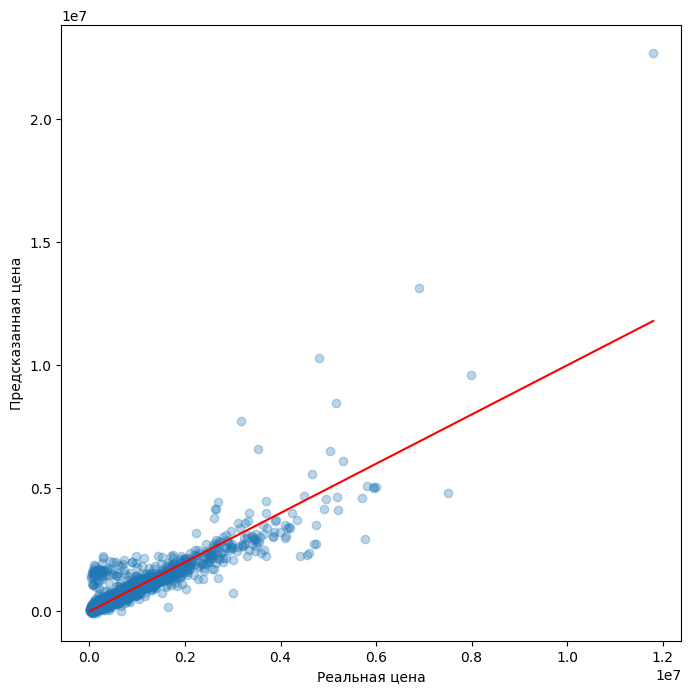

In [ ]:
# Предсказание на тестовой выборке
pred_scaled = model.predict(x_test)

# Обратное масштабирование в рубли
pred_rub = scaler_y.inverse_transform(pred_scaled).flatten()
y_test_rub = scaler_y.inverse_transform(y_test).flatten()

# Расчет MAE (средний модуль ошибки) в рублях
mae = np.mean(np.abs(pred_rub - y_test_rub))

# Суммарный процент ошибки
error_percentage = (mae / mean_price) * 100

print(f"Средняя ошибка (MAE): {round(mae, 2)} руб.")
print(f"Суммарный процент ошибки: {round(error_percentage, 2)}%")

# Построение графика разброса
plt.figure(figsize=(8, 8))
plt.scatter(y_test_rub, pred_rub, alpha=0.3)
plt.plot([0, max(y_test_rub)], [0, max(y_test_rub)], 'r')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.show()